# **Proyek Akhir: Menyelesaikan Permasalahan Institusi Pendidikan**

* Name: Rizky Putra Reinanda
* Email: reinanda1908@gmail.com
* Dicoding ID: reinanda_13

# **Persiapan**

Menyiapkan library yang dibutuhkan

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import collections
import joblib

from imblearn.over_sampling import SMOTE
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split, GridSearchCV

from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report

df = pd.read_csv('student_data_filtered.csv')

Notebook siap dijalankan.

**Menyiapkan data yang akan digunakan**

In [2]:
dataset_url = 'https://raw.githubusercontent.com/dicodingacademy/dicoding_dataset/refs/heads/main/students_performance/data.csv'

df = pd.read_csv(dataset_url, delimiter=';')
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


### Dataset Summary

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4424 entries, 0 to 4423
Data columns (total 37 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Marital_status                                4424 non-null   int64  
 1   Application_mode                              4424 non-null   int64  
 2   Application_order                             4424 non-null   int64  
 3   Course                                        4424 non-null   int64  
 4   Daytime_evening_attendance                    4424 non-null   int64  
 5   Previous_qualification                        4424 non-null   int64  
 6   Previous_qualification_grade                  4424 non-null   float64
 7   Nacionality                                   4424 non-null   int64  
 8   Mothers_qualification                         4424 non-null   int64  
 9   Fathers_qualification                         4424 non-null   i

The data contains information at the time of student enrollment, such as academic path, demographic information, and socio-economic factors, along with their academic performance at the conclusion of the first and second semesters.

* **Marital status** - The marital status of the student
* **Application mode** - The method of application used by the student
* **Application order** - The order in which the student applied (between 0 - first choice; and 9 last choice)
* **Course** - The course taken by the student
* **Daytime/evening attendance** - Whether the student attends classes during the day or in the evening
* **Previous qualification** - The qualification obtained by the student before enrolling in higher education
* **Previous qualification (grade)** - Grade of previous qualification (between 0 and 200)
* **Nacionality** - The nationality of the student
* **Mother's qualification** - The qualification of the student's mother
* **Father's qualification** - The qualification of the student's father
* **Mother's occupation** - The occupation of the student's mother
* **Father's occupation** - The occupation of the student's father
* **Admission grade** - Admission grade (between 0 and 200)
* **Displaced** - Whether the student is a displaced person (1-yes, 0-no)
* **Educational special needs** - Whether the student has any special educational needs (1-yes, 0-no)
* **Debtor** - Whether the student is a debtor (1-yes, 0-no)
* **Tuition fees up to date** - Whether the student's tuition fees are up to date (1-yes, 0-no)
* **Gender** - The gender of the student (1-male, 0-female)
* **Scholarship holder** - Whether the student is a scholarship holder (1-yes, 0-no)
* **Age at enrollment** - The age of the student at the time of enrollment
* **International** - Whether the student is an international student (1-yes, 0-no)
* **Curricular units 1st sem (credited)** - The number of curricular units credited by the student in the first semester
* **Curricular units 1st sem (enrolled)** - The number of curricular units enrolled by the student in the first semester
* **Curricular units 1st sem (evaluations)** - The number of curricular units evaluated by the student in the first semester
* **Curricular units 1st sem (approved)** - The number of curricular units approved by the student in the first semester

Periksa nilai unik dari setiap fitur data kategorikal

In [4]:
for feature in df.select_dtypes(include='object'):
    print(feature)
    print(df[feature].unique(), '\n')

Status
['Dropout' 'Graduate' 'Enrolled'] 



Statistik deskriptif dataset untuk data numerik dan kategorikal.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
Marital_status,4424.0,1.178571,0.605747,1.00,1.00,1.000000,1.000000,6.000000
Application_mode,4424.0,18.669078,17.484682,1.00,1.00,17.000000,39.000000,57.000000
Application_order,4424.0,1.727848,1.313793,0.00,1.00,1.000000,2.000000,9.000000
Course,4424.0,8856.642631,2063.566416,33.00,9085.00,9238.000000,9556.000000,9991.000000
Daytime_evening_attendance,4424.0,0.890823,0.311897,0.00,1.00,1.000000,1.000000,1.000000
Previous_qualification,4424.0,4.577758,10.216592,1.00,1.00,1.000000,1.000000,43.000000
Previous_qualification_grade,4424.0,132.613314,13.188332,95.00,125.00,133.100000,140.000000,190.000000
Nacionality,4424.0,1.873192,6.914514,1.00,1.00,1.000000,1.000000,109.000000
Mothers_qualification,4424.0,19.561935,15.603186,1.00,2.00,19.000000,37.000000,44.000000
Fathers_qualification,4424.0,22.275316,15.343108,1.00,3.00,19.000000,37.000000,44.000000


In [6]:
df.describe(include='object').T

,count,unique,top,freq
Status,4424,3,Graduate,2209


### Missing Value and Duplicate Data Handling

Check for missing value / Cek data yang kosong.

In [7]:
print(df.isnull().sum())

Marital_status                                  0
Application_mode                                0
Application_order                               0
Course                                          0
Daytime_evening_attendance                      0
Previous_qualification                          0
Previous_qualification_grade                    0
Nacionality                                     0
Mothers_qualification                           0
Fathers_qualification                           0
Mothers_occupation                              0
Fathers_occupation                              0
Admission_grade                                 0
Displaced                                       0
Educational_special_needs                       0
Debtor                                          0
Tuition_fees_up_to_date                         0
Gender                                          0
Scholarship_holder                              0
Age_at_enrollment                               0


Check for data duplicates / Cek duplikasi data

In [8]:
df.duplicated().sum()

np.int64(0)

Karena tidak ada nilai yang hilang dan data duplikat dalam dataset, kita dapat melanjutkan ke proses selanjutnya.

### Unique Data

Check for unique data / Cek data atau nilai unik

In [9]:
print(df.nunique())

Marital_status                                    6
Application_mode                                 18
Application_order                                 8
Course                                           17
Daytime_evening_attendance                        2
Previous_qualification                           17
Previous_qualification_grade                    101
Nacionality                                      21
Mothers_qualification                            29
Fathers_qualification                            34
Mothers_occupation                               32
Fathers_occupation                               46
Admission_grade                                 620
Displaced                                         2
Educational_special_needs                         2
Debtor                                            2
Tuition_fees_up_to_date                           2
Gender                                            2
Scholarship_holder                                2
Age_at_enrol

### Label Decoding

Pengodean balik label untuk fitur-fitur di bawah ini.

| Features | 0 | 1 | 2 | 3 | 4 | 5 | 6 |
|----------|---|---|---|---|---|---|---|
| **Marital_status** | - | Single | Married | Widower | Divorced | Facto Union | Legally Seperated |
| **Daytime_evening_attendance** | Evening | Daytime | - | - | - | - | - |
| **Displaced** | No | Yes | - | - | - | - | - |
| **Educational_special_needs** | No | Yes | - | - | - | - | - |
| **Debtor** | No | Yes | - | - | - | - | - |
| **Tuition_fees_up_to_date** | No | Yes | - | - | - | - | - |
| **Gender** | Female | Male | - | - | - | - | - |
| **Scholarship_holder** | No | Yes | - | - | - | - | - |
| **International** | No | Yes | - | - | - | - | - |

<br>

<details>
<summary><b>Application_mode</b></summary>
1 - 1st Phase - General Contingent<br>
2 - Ordinance No. 612/93<br>
5 - 1st Phase - Special Contingent (Azores Island)<br>
7 - Holders of Other Higher Courses<br>
10 - Ordinance No. 854-B/99<br>
15 - International Student (Bachelor)<br>
16 - 1st phase - Special Contingent (Madeira Island)<br>
17 - 2nd phase - General Contingent<br>
18 - 3rd phase - General Contingent<br>
26 - Ordinance No. 533-A/99, Item B2 (Different Plan)<br>
27 - Ordinance No. 533-A/99, Item B3 (Other Institution)<br>
39 - Over 23 Years Old<br>
42 - Transfer<br>
43 - Change of Course<br>
44 - Technological Specialization Diploma Holders<br>
51 - Change of Institution/Course<br>
53 - Short Cycle Diploma Holders<br>
57 - Change of Institution/Course (International)<br>
</details>

<br>

<details>
<summary><b>Course</b></summary>
33 - Biofuel Production Technologies<br>
171 - Animation and Multimedia Design<br>
8014 - Social Service (Evening Attendance)<br>
9003 - Agronomy<br>
9070 - Communication Design<br>
9085 - Veterinary Nursing<br>
9119 - Informatics Engineering<br>
9130 - Equinculture<br>
9147 - Management<br>
9238 - Social Service<br>
9254 - Tourism<br>
9500 - Nursing<br>
9556 - Oral Hygiene<br>
9670 - Advertising and Marketing Management<br>
9773 - Journalism and Communication<br>
9853 - Basic Education<br>
9991 - Management (Evening Attendance)<br>
</details>

<br>

<details>
<summary><b>Previous_qualification</b></summary>
1 - Secondary Education<br>
2 - Higher Education - Bachelor's Degree<br>
3 - Higher Education - Degree<br>
4 - Higher Education - Master's<br>
5 - Higher Education - Doctorate<br>
6 - Frequency of Higher Education<br>
9 - 12th Year of Schooling - Not Completed<br>
10 - 11th Year of Schooling - Not Completed<br>
12 - Other - 11th Year of Schooling<br>
14 - 10th Year of Schooling<br>
15 - 10th Year of Schooling - Not Completed<br>
19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.<br>
38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.<br>
39 - Technological Specialization Course<br>
40 - Higher Education - Degree (1st Cycle)<br>
42 - Professional Higher Technical Course<br>
43 - Higher Education - Master (2nd Cycle)<br>
</details>

<br>

<details>
<summary><b>Nacionality</b></summary>
1 - Portuguese<br>
2 - German<br>
6 - Spanish<br>
11 - Italian<br>
13 - Dutch<br>
14 - English<br>
17 - Lithuanian<br>
21 - Angolan<br>
22 - Cape Verdean<br>
24 - Guinean<br>
25 - Mozambican<br>
26 - Santomean<br>
32 - Turkish<br>
41 - Brazilian<br>
62 - Romanian<br>
100 - Moldova (Republic of)<br>
101 - Mexican<br>
103 - Ukrainian<br>
105 - Russian<br>
108 - Cuban<br>
109 - Colombian<br>
</details>

<br>

<details>
<summary><b>Mothers_qualification & Fathers_qualification</b></summary>
1 - Secondary Education - 12th Year of Schooling or Eq.<br>
2 - Higher Education - Bachelor's Degree<br>
3 - Higher Education - Degree<br>
4 - Higher Education - Master's<br>
5 - Higher Education - Doctorate<br>
6 - Frequency of Higher Education<br>
9 - 12th Year of Schooling - Not Completed<br>
10 - 11th Year of Schooling - Not Completed<br>
11 - 7th Year (Old)<br>
12 - Other - 11th Year of Schooling<br>
13 - 2nd Year Complementary High School Course<br>
14 - 10th Year of Schooling<br>
18 - General Commerce Course<br>
19 - Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.<br>
20 - Complementary High School Course<br>
22 - Technical - Professional Course<br>
25 - Complementary High School Course - Not Concluded<br>
26 - 7th Year of Schooling<br>
27 - 2nd Cycle of the General High School Course<br>
29 - 9th Year of Schooling - Not Completed<br>
30 - 8th Year of Schooling<br>
31 - General Course of Administration and Commerce<br>
33 - Supplementary Accounting and Administration<br>
34 - Unknown<br>
35 - Can't Read or Write<br>
36 - Can Read Without Having a 4th Year of Schooling<br>
37 - Basic Education 1st Cycle (4th/5th Year) or Equiv.<br>
38 - Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.<br>
39 - Technological Specialization Course<br>
40 - Higher Education - Degree (1st Cycle)<br>
41 - Specialized Higher Studies Course<br>
42 - Professional Higher Technical Course<br>
43 - Higher Education - Master (2nd Cycle)<br>
44 - Higher Education - Doctorate (3rd Cycle)<br>
</details>

<br>

<details>
<summary><b>Mothers_occupation & Fathers_occupation</b></summary>
0 - Student<br>
1 - Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers<br>
2 - Specialists in Intellectual and Scientific Activities<br>
3 - Intermediate Level Technicians and Professions<br>
4 - Administrative Staff<br>
5 - Personal Services, Security and Safety Workers and Sellers<br>
6 - Farmers and Skilled Workers in Agriculture, Fisheries and Forestry<br>
7 - Skilled Workers in Industry, Construction and Craftsmen<br>
8 - Installation and Machine Operators and Assembly Workers<br>
9 - Unskilled Workers<br>
10 - Armed Forces Professions<br>
90 - Other Situation<br>
99 - (Blank)<br>
101 - Armed Forces Officers<br>
102 - Armed Forces Sergeants<br>
103 - Other Armed Forces Personnel<br>
112 - Directors of Administrative and Commercial Services<br>
114 - Hotel, Catering, Trade and Other Services Directors<br>
121 - Specialists in the Physical Sciences, Mathematics, Engineering and Related Techniques<br>
122 - Health Professionals<br>
123 - Teachers<br>
124 - Specialists in Finance, Accounting, Administrative Organization, Public and Commercial Relations<br>
125 - Specialists in Information and Communication Technologies (ICT)<br>
131 - Intermediate Level Science and Engineering Technicians and Professions<br>
132 - Technicians and Professionals, of Intermediate Level of Health<br>
134 - Intermediate Level Technicians From Legal, Social, Sports, Cultural and Similar Services<br>
135 - Information and Communication Technology Technicians<br>
141 - Office Workers, Secretaries in General and Data Processing Operators<br>
143 - Data, Accounting, Statistical, Financial Services and Registry-Related Operators<br>
144 - Other Administrative Support Staff<br>
151 - Personal Service Workers<br>
152 - Sellers<br>
153 - Personal Care Workers and the Like<br>
154 - Protection and Security Services Personnel<br>
161 - Market-Oriented Farmers and Skilled Agricultural and Animal Production Workers<br>
163 - Farmers, Livestock Keepers, Fishermen, Hunters and Gatherers, Subsistence<br>
171 - Skilled Construction Workers and the Like, Except Electricians<br>
172 - Skilled Workers in Metallurgy, Metalworking and Similar<br>
173 - Skilled Workers in Printing, Precision Instrument Manufacturing, Jewelers, Artisans and the Like<br>
174 - Skilled Workers in Electricity and Electronics<br>
175 - Workers in Food Processing, Woodworking, Clothing and Other Industries and Crafts<br>
181 - Fixed Plant and Machine Operators<br>
182 - Assembly Workers<br>
183 - Vehicle Drivers and Mobile Equipment Operators<br>
191 - Cleaning Workers<br>
192 - Unskilled Workers in Agriculture, Animal Production, Fisheries and Forestry<br>
193 - Unskilled Workers in Extractive Industry, Construction, Manufacturing and Transport<br>
194 - Meal Preparation Assistants<br>
195 - Street Vendors (Except Food) and Street Service Providers<br>
</details>

In [10]:
def label_decoding(df, feature):
    """
    Transform encoded feature in a DataFrame to their respective categorical labels

    Parameters
        df (pandas.DataFrame) : The DataFrame containing the feature to be transformed
        feature (str or list of str) : The name of the feature to be transformed

    Returns
        pandas.DataFrame : The DataFrame with the specified feature as categorical labels
    """

    category_mappings = {
        'Marital_status': {1: 'Single', 2: 'Married', 3: 'Widower', 4: 'Divorced',
                           5: 'Facto Union', 6: 'Legally Seperated'},
        'Daytime_evening_attendance': {0: 'Evening', 1: 'Daytime'},
        'Gender': {0: 'Female', 1: 'Male'},
        'Application_mode' : {
            1: '1st Phase - General Contingent',
            2: 'Ordinance No. 612/93',
            5: '1st Phase - Special Contingent (Azores Island)',
            7: 'Holders of Other Higher Courses',
            10: 'Ordinance No. 854-B/99',
            15: 'International Student (Bachelor)',
            16: '1st Phase - Special Contingent (Madeira Island)',
            17: '2nd Phase - General Contingent',
            18: '3rd Phase - General Contingent',
            26: 'Ordinance No. 533-A/99, Item B2 (Different Plan)',
            27: 'Ordinance No. 533-A/99, Item B3 (Other Institution)',
            39: 'Over 23 Years Old',
            42: 'Transfer',
            43: 'Change of Course',
            44: 'Technological Specialization Diploma Holders',
            51: 'Change of Institution/Course',
            53: 'Short Cycle Diploma Holders',
            57: 'Change of Institution/Course (International)'
        },
        'Course': {
            33: 'Biofuel Production Technologies',
            171: 'Animation and Multimedia Design',
            8014: 'Social Service (Evening Attendance)',
            9003: 'Agronomy',
            9070: 'Communication Design',
            9085: 'Veterinary Nursing',
            9119: 'Informatics Engineering',
            9130: 'Equinculture',
            9147: 'Management',
            9238: 'Social Service',
            9254: 'Tourism',
            9500: 'Nursing',
            9556: 'Oral Hygiene',
            9670: 'Advertising and Marketing Management',
            9773: 'Journalism and Communication',
            9853: 'Basic Education',
            9991: 'Management (Evening Attendance)'
        },
        'Nacionality': {
            1: 'Portuguese', 2: 'German', 6: 'Spanish', 11: 'Italian',
            13: 'Dutch', 14: 'English', 17: 'Lithuanian', 21: 'Angolan',
            22: 'Cape Verdean', 24: 'Guinean', 25: 'Mozambican',
            26: 'Santomean', 32: 'Turkish', 41: 'Brazilian', 62: 'Romanian',
            100: 'Moldova (Republic of)', 101: 'Mexican', 103: 'Ukrainian',
            105: 'Russian', 108: 'Cuban', 109: 'Colombian'
        },
        'Qualification': {
            1: 'Secondary Education - 12th Year of Schooling or Eq.',
            2: "Higher Education - Bachelor's Degree",
            3: 'Higher Education - Degree',
            4: "Higher Education - Master's",
            5: 'Higher Education - Doctorate',
            6: 'Frequency of Higher Education',
            9: '12th Year of Schooling - Not Completed',
            10: '11th Year of Schooling - Not Completed',
            11: '7th Year (Old)',
            12: 'Other - 11th Year of Schooling',
            13: '2nd Year Complementary High School Course',
            14: '10th Year of Schooling',
            15: '10th Year of Schooling - Not Completed',
            18: 'General Commerce Course',
            19: 'Basic Education 3rd Cycle (9th/10th/11th Year) or Equiv.',
            20: 'Complementary High School Course',
            22: 'Technical - Professional Course',
            25: 'Complementary High School Course - Not Concluded',
            26: '7th Year of Schooling',
            27: '2nd Cycle of the General High School Course',
            29: '9th Year of Schooling - Not Completed',
            30: '8th Year of Schooling',
            31: 'General Course of Administration and Commerce',
            33: 'Supplementary Accounting and Administration',
            34: 'Unknown',
            35: "Can't Read or Write",
            36: 'Can Read Without Having a 4th Year of Schooling',
            37: 'Basic Education 1st Cycle (4th/5th Year) or Equiv.',
            38: 'Basic Education 2nd Cycle (6th/7th/8th Year) or Equiv.',
            39: 'Technological Specialization Course',
            40: 'Higher Education - Degree (1st Cycle)',
            41: 'Specialized Higher Studies Course',
            42: 'Professional Higher Technical Course',
            43: 'Higher Education - Master (2nd Cycle)',
            44: 'Higher Education - Doctorate (3rd Cycle)'
        },
        'Occupation': {
            0: 'Student',
            1: 'Representatives of the Legislative Power and Executive Bodies, Directors, Directors and Executive Managers',
            2: 'Specialists in Intellectual and Scientific Activities',
            3: 'Intermediate Level Technicians and Professions',
            4: 'Administrative Staff',
            5: 'Personal Services, Security and Safety Workers and Sellers',
            6: 'Farmers and Skilled Workers in Agriculture, Fisheries and Forestry',
            7: 'Skilled Workers in Industry, Construction and Craftsmen',
            8: 'Installation and Machine Operators and Assembly Workers',
            9: 'Unskilled Workers',
            10: 'Armed Forces Professions',
            90: 'Other Situation',
            99: '(Blank)',
            101: 'Armed Forces Officers',
            102: 'Armed Forces Sergeants',
            103: 'Other Armed Forces Personnel',
            112: 'Directors of Administrative and Commercial Services',
            114: 'Hotel, Catering, Trade and Other Services Directors',
            121: 'Specialists in the Physical Sciences, Mathematics, Engineering and Related Techniques',
            122: 'Health Professionals',
            123: 'Teachers',
            124: 'Specialists in Finance, Accounting, Administrative Organization, Public and Commercial Relations',
            125: 'Specialists in Information and Communication Technologies (ICT)',
            131: 'Intermediate Level Science and Engineering Technicians and Professions',
            132: 'Technicians and Professionals, of Intermediate Level of Health',
            134: 'Intermediate Level Technicians From Legal, Social, Sports, Cultural and Similar Services',
            135: 'Information and Communication Technology Technicians',
            141: 'Office Workers, Secretaries in General and Data Processing Operators',
            143: 'Data, Accounting, Statistical, Financial Services and Registry-Related Operators',
            144: 'Other Administrative Support Staff',
            151: 'Personal Service Workers',
            152: 'Sellers',
            153: 'Personal Care Workers and the Like',
            154: 'Protection and Security Services Personnel',
            161: 'Market-Oriented Farmers and Skilled Agricultural and Animal Production Workers',
            163: 'Farmers, Livestock Keepers, Fishermen, Hunters and Gatherers, Subsistence',
            171: 'Skilled Construction Workers and the Like, Except Electricians',
            172: 'Skilled Workers in Metallurgy, Metalworking and Similar',
            173: 'Skilled Workers in Printing, Precision Instrument Manufacturing, Jewelers, Artisans and the Like',
            174: 'Skilled Workers in Electricity and Electronics',
            175: 'Workers in Food Processing, Woodworking, Clothing and Other Industries and Crafts',
            181: 'Fixed Plant and Machine Operators',
            182: 'Assembly Workers',
            183: 'Vehicle Drivers and Mobile Equipment Operators',
            191: 'Cleaning Workers',
            192: 'Unskilled Workers in Agriculture, Animal Production, Fisheries and Forestry',
            193: 'Unskilled Workers in Extractive Industry, Construction, Manufacturing and Transport',
            194: 'Meal Preparation Assistants',
            195: 'Street Vendors (Except Food) and Street Service Providers'
        }
    }

    category_mappings['Previous_qualification'] = category_mappings['Qualification']
    category_mappings['Mothers_qualification'] = category_mappings['Qualification']
    category_mappings['Fathers_qualification'] = category_mappings['Qualification']
    category_mappings['Mothers_occupation'] = category_mappings['Occupation']
    category_mappings['Fathers_occupation'] = category_mappings['Occupation']

    binary_features = ['Displaced', 'Educational_special_needs', 'Debtor',
                       'Tuition_fees_up_to_date', 'Scholarship_holder',
                       'International']
    binary_mapping = {0: 'No', 1: 'Yes'}

    features = [feature] if isinstance(feature, str) else feature

    for f in features:
        if f in category_mappings:
            df[f] = df[f].map(category_mappings[f])
        elif f in binary_features:
            df[f] = df[f].map(binary_mapping)

    return df

In [11]:
df_eda = df.copy()

df_eda = label_decoding(df_eda, ['Marital_status', 'Application_mode', 'Course',
                                 'Daytime_evening_attendance',
                                 'Previous_qualification', 'Nacionality',
                                 'Mothers_qualification', 'Fathers_qualification',
                                 'Mothers_occupation', 'Fathers_occupation',
                                 'Displaced', 'Educational_special_needs' ,
                                 'Debtor', 'Tuition_fees_up_to_date', 'Gender',
                                 'Scholarship_holder', 'International'])

df_eda

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,Single,2nd Phase - General Contingent,5,Animation and Multimedia Design,Daytime,Secondary Education - 12th Year of Schooling o...,122.0,Portuguese,Basic Education 3rd Cycle (9th/10th/11th Year)...,Other - 11th Year of Schooling,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,Dropout
1,Single,International Student (Bachelor),1,Tourism,Daytime,Secondary Education - 12th Year of Schooling o...,160.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Higher Education - Degree,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,Graduate
2,Single,1st Phase - General Contingent,5,Communication Design,Daytime,Secondary Education - 12th Year of Schooling o...,122.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,Dropout
3,Single,2nd Phase - General Contingent,2,Journalism and Communication,Daytime,Secondary Education - 12th Year of Schooling o...,122.0,Portuguese,Basic Education 2nd Cycle (6th/7th/8th Year) o...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,Graduate
4,Married,Over 23 Years Old,1,Social Service (Evening Attendance),Evening,Secondary Education - 12th Year of Schooling o...,100.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 2nd Cycle (6th/7th/8th Year) o...,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,Graduate
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4419,Single,1st Phase - General Contingent,6,Journalism and Communication,Daytime,Secondary Education - 12th Year of Schooling o...,125.0,Portuguese,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,Graduate
4420,Single,1st Phase - General Contingent,2,Journalism and Communication,Daytime,Secondary Education - 12th Year of Schooling o...,120.0,Russian,Secondary Education - 12th Year of Schooling o...,Secondary Education - 12th Year of Schooling o...,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,Dropout
4421,Single,1st Phase - General Contingent,1,Nursing,Daytime,Secondary Education - 12th Year of Schooling o...,154.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,Dropout
4422,Single,1st Phase - General Contingent,1,Management,Daytime,Secondary Education - 12th Year of Schooling o...,180.0,Portuguese,Basic Education 1st Cycle (4th/5th Year) or Eq...,Basic Education 1st Cycle (4th/5th Year) or Eq...,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,Graduate


In [12]:
for feature in df_eda.select_dtypes(include='object'):
    print(feature)
    print(df_eda[feature].unique(), '\n')

Marital_status
['Single' 'Married' 'Divorced' 'Widower' 'Facto Union' 'Legally Seperated'] 

Application_mode
['2nd Phase - General Contingent' 'International Student (Bachelor)'
 '1st Phase - General Contingent' 'Over 23 Years Old'
 '3rd Phase - General Contingent' 'Short Cycle Diploma Holders'
 'Technological Specialization Diploma Holders'
 'Change of Institution/Course' 'Change of Course'
 'Holders of Other Higher Courses' 'Transfer'
 '1st Phase - Special Contingent (Madeira Island)'
 '1st Phase - Special Contingent (Azores Island)' 'Ordinance No. 612/93'
 'Ordinance No. 854-B/99' 'Change of Institution/Course (International)'
 'Ordinance No. 533-A/99, Item B2 (Different Plan)'
 'Ordinance No. 533-A/99, Item B3 (Other Institution)'] 

Course
['Animation and Multimedia Design' 'Tourism' 'Communication Design'
 'Journalism and Communication' 'Social Service (Evening Attendance)'
 'Management (Evening Attendance)' 'Nursing' 'Social Service'
 'Advertising and Marketing Management' 'Bas

### Label Encoding

Melakukan pengodean label Encoding pada fitur Status

In [13]:
le = LabelEncoder()
df['Status'] = le.fit_transform(df['Status'])

dict(zip(le.classes_, le.transform(le.classes_)))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

### Cleaned Data Export

Ekspor dataset yang telah dibersihkan

In [14]:
# Dataset for Business Dashboard
df_eda.to_csv('student_data_cleaned.csv', index=False)

# **Data Understanding**

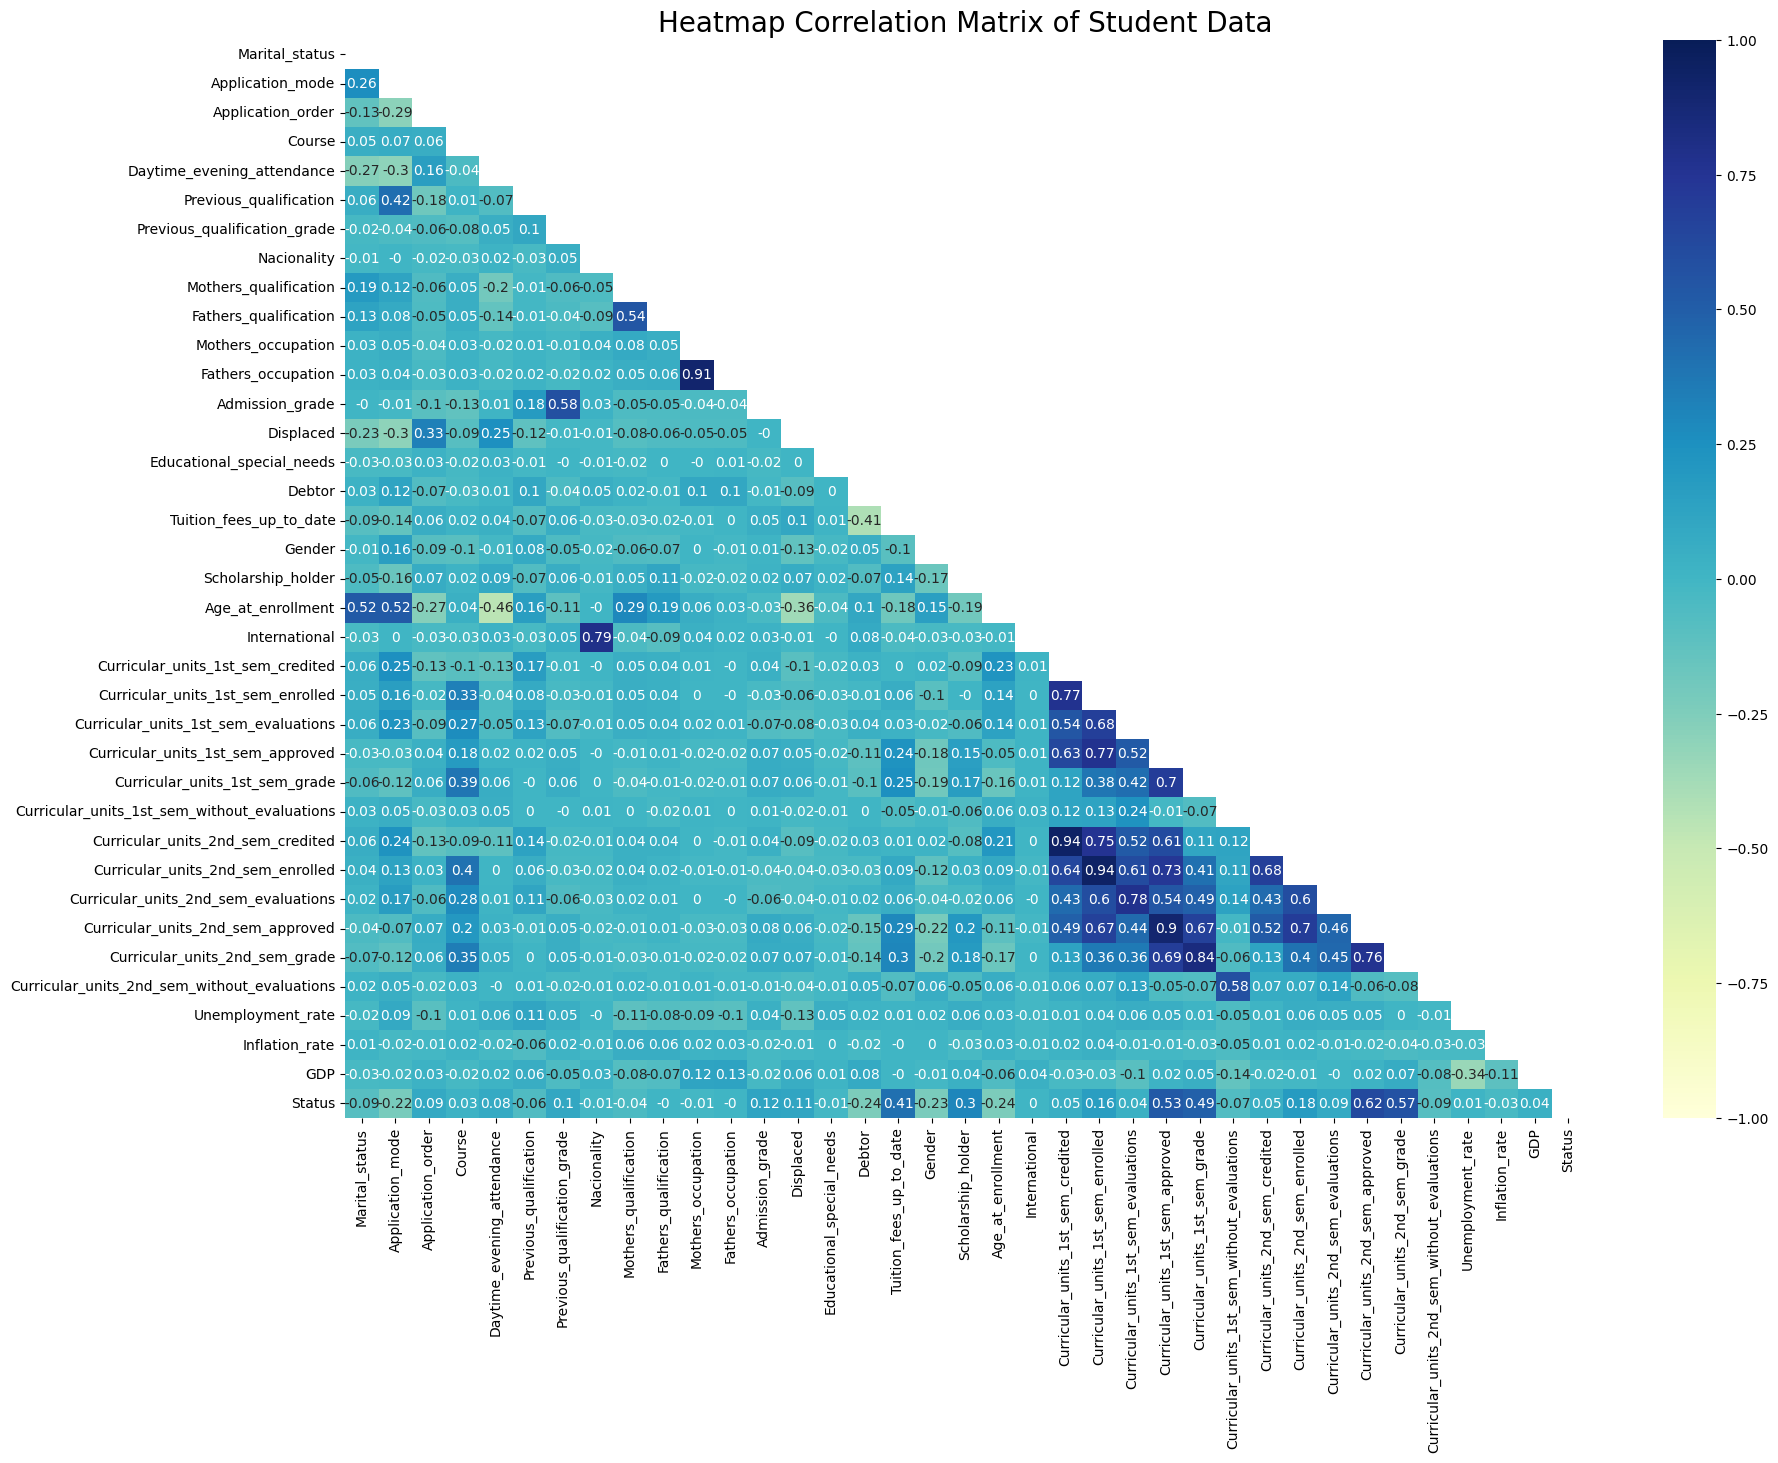

In [15]:
plt.figure(figsize=(20, 14))
correlation_matrix = df.corr(numeric_only=True).round(2)
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix, vmin=-1, vmax=1,annot=True, cmap='YlGnBu', mask=mask)
plt.title('Heatmap Correlation Matrix of Student Data', size=20)
plt.show()

Berdasarkan plot matriks korelasi di atas, beberapa poin terkait dengan `Status` adalah:
1. Features that have a **fairly strong** influence on `Status` are `Curricular_units_2nd_sem_approved` and `Curricular_units_2nd_sem_grade`. 
2. Features that have a **moderate** influence on `Status` are `Curricular_units_1nd_sem_approved`, `Curricular_units_1nd_sem_grade`, `Tuition_fees_up_to_date`, and `Scholarship_holder`.
3. Features that have a **low** influence on `Status` are `Age_at_enrollment`, `Debtor`, `Gender`, and `Applicatoin_mode`. 
4. And the rest are features that have a **very weak** influence on `Status`.

In [16]:
# @title Define Pie Plot
def pie_plot(data, title):
    """
    Create a pie chart for the distribution of a categorical column.

    Parameters:
    - data: DataFrame, the dataset to plot.
    - title: str, the title of the plot.

    Returns:
    This function does not return any value but displays a pie chart.
    """
    data = data.value_counts()
    plt.pie(data, labels=data.index,
            autopct=lambda pct: f'{int(pct/100.*data.sum())} ({pct:.2f}%)')
    plt.title(f'Distribution of {title}')
    plt.show()

In [17]:
# @title Define Count Plot
def count_plot(data, y, hue=None, title='Data', figsize=(8, 4)):
    """
    Create a countplot with annotations for a given dataset.

    Parameters:
    - data: DataFrame, the dataset to plot.
    - y: str, the column to plot on the y-axis.
    - hue: str, optional, the column for hue categorization.
    - title: str, the title of the plot.
    - figsize: tuple, the size of the figure.

    Returns:
    - This function does not return any value but displays a countplot.
    """
    plt.figure(figsize=figsize)
    ax = sns.countplot(data=data, y=y, hue=hue,
                    order=data[y].value_counts().index)
    plt.title(f'Distribution of {title}')
    plt.grid()

    if hue:
        plt.legend(loc='lower right')

    # Add annotation label to each bar
    for bar in ax.patches:
        if bar.get_width() > 0 and bar.get_height() > 0:
            ax.annotate(
                f'{int(bar.get_width())}',
                (bar.get_width(), bar.get_y() + bar.get_height() / 2),
                ha='left', va='center', textcoords='offset points', xytext=(5, 0))

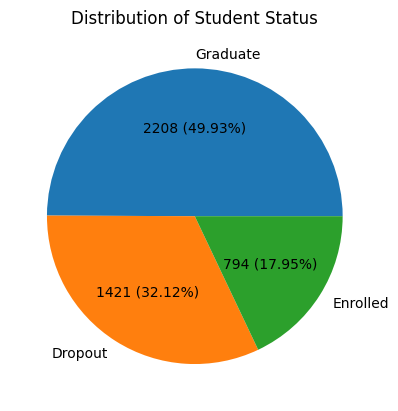

In [18]:
pie_plot(df_eda['Status'], 'Student Status')

Mahasiswa dengan status Graduate memiliki persentase tertinggi, yaitu 49,93%, diikuti oleh mahasiswa dengan status Dropout sebesar 32,12%, dan status Enrolled yang memiliki persentase terendah, hanya 17,95%.

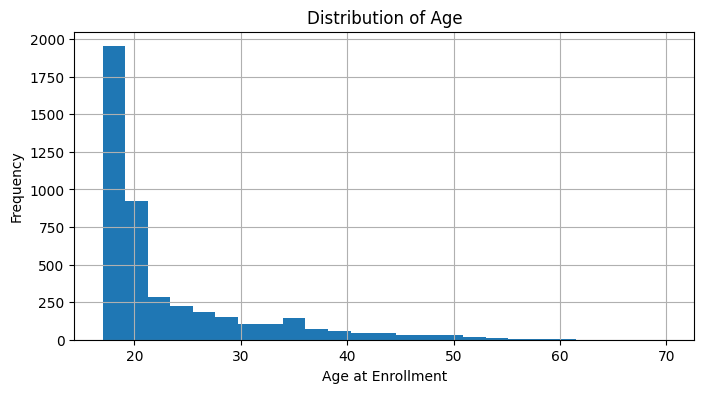

In [19]:
plt.figure(figsize=(8, 4))
plt.hist(df_eda['Age_at_enrollment'], bins=25)
plt.title('Distribution of Age')
plt.xlabel('Age at Enrollment')
plt.ylabel('Frequency')
plt.grid()
plt.show()

Mayoritas mahasiswa yang mendaftar berusia antara 17 hingga 20 tahun.

C:\Users\Ifan\AppData\Local\Temp\ipykernel_16472\1994707596.py:23: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc='lower right')


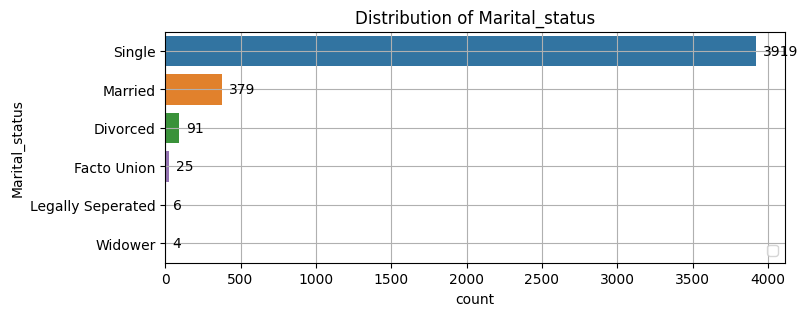

In [20]:
count_plot(df_eda, 'Marital_status', 'Marital_status', 'Marital_status', (8, 3))

Sebagian besar mahasiswa memiliki Status Belum Menikah.

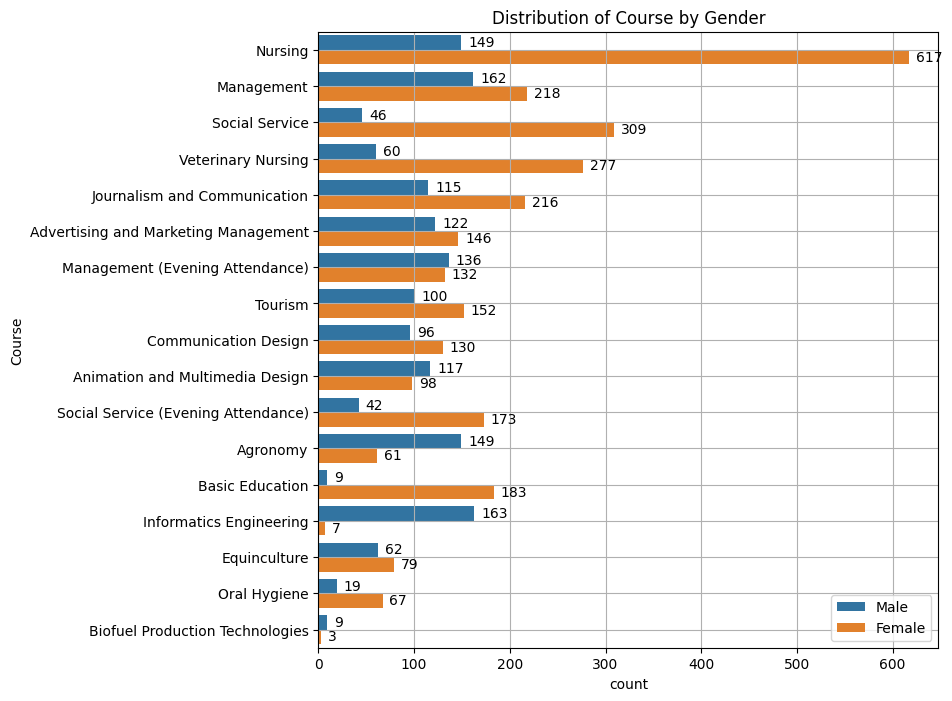

In [21]:
count_plot(df_eda, 'Course', 'Gender', 'Course by Gender', (8, 8))

Kursus dengan data terbanyak adalah Keperawatan (Nursing) dengan jenis kelamin dominan Perempuan dibandingkan Laki-laki. Sementara itu, kursus dengan data paling sedikit adalah Teknologi Produksi Biofuel (Biofuel Production Technologies) dengan dominasi Laki-laki. Selain itu, mahasiswa Laki-laki paling banyak berada di kursus Teknik Informatika dan Manajemen.

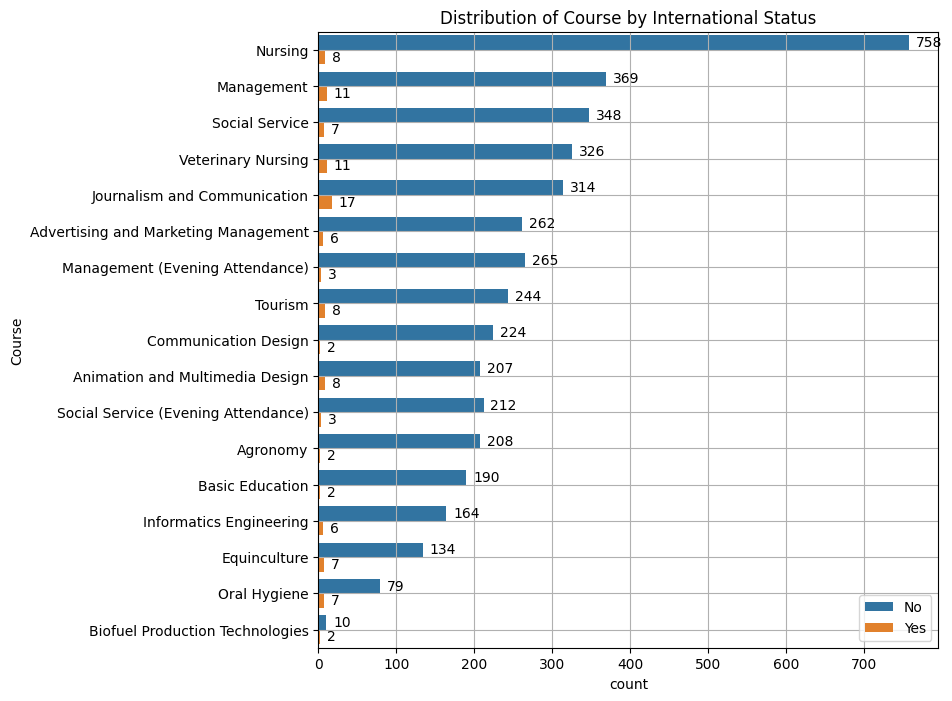

In [22]:
count_plot(df_eda, 'Course', 'International', 'Course by International Status', (8, 8))

Secara keseluruhan, terdapat lebih banyak mahasiswa lokal dibandingkan mahasiswa internasional. Mahasiswa internasional lebih cenderung mengambil kursus Jurnalisme dan Komunikasi.

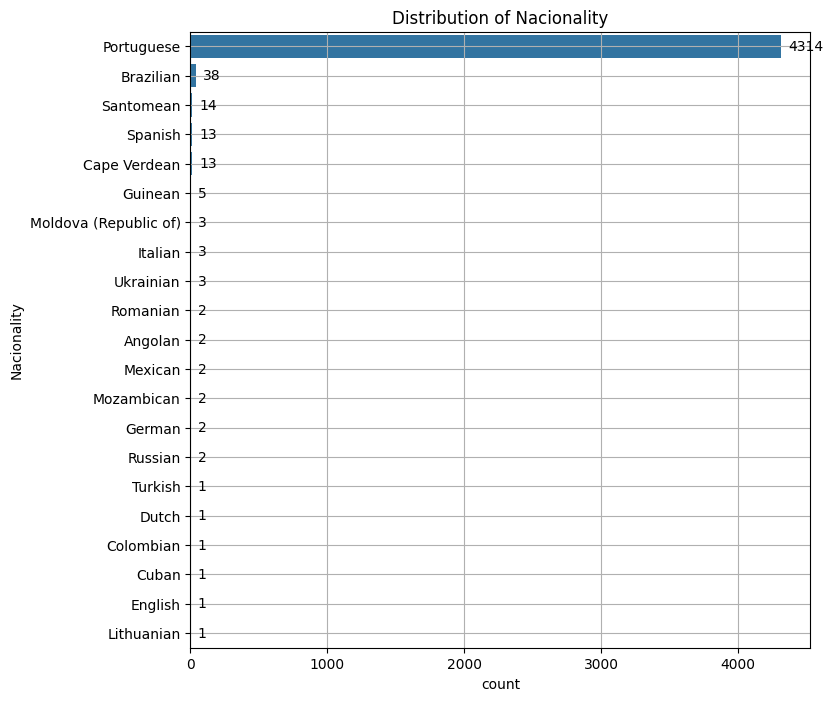

In [23]:
count_plot(df_eda, 'Nacionality', title='Nacionality', figsize=(8, 8))

Data kewarganegaraan mahasiswa internasional terbanyak berasal dari Portugal, yaitu sebesar 97,51% dibandingkan dengan yang lainnya

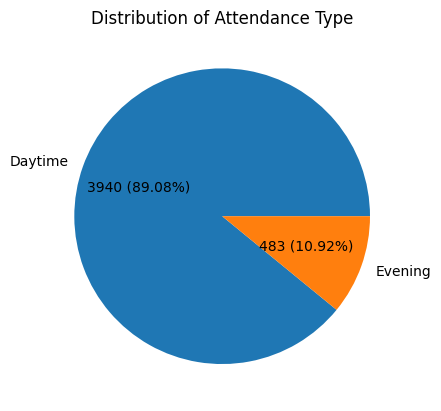

In [24]:
pie_plot(df_eda['Daytime_evening_attendance'], 'Attendance Type')

Mahasiswa dengan kehadiran di siang hari (Daytime) memiliki persentase tertinggi, yaitu 89,08%, sedangkan mahasiswa yang hadir di malam hari (Evening) hanya sebesar 10,92%.

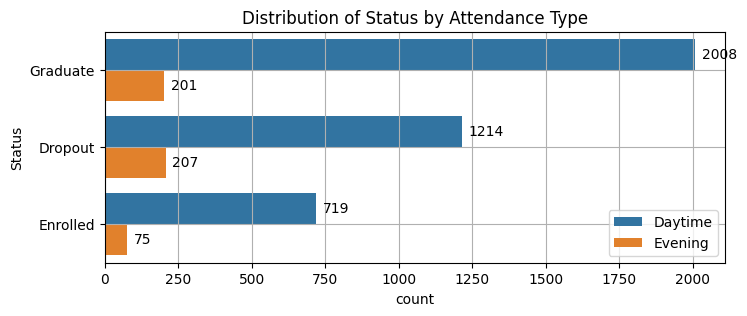

In [25]:
count_plot(df_eda, 'Status', 'Daytime_evening_attendance', 'Status by Attendance Type', (8, 3))

Sebagian besar mahasiswa memilih untuk belajar di kelas siang hari daripada kelas malam untuk ketiga status tersebut, baik mereka yang Graduate, Dropout, maupun yang Enrolled.

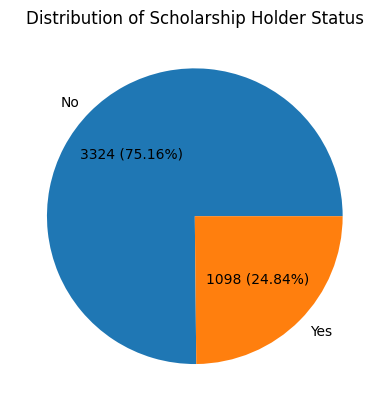

In [26]:
pie_plot(df_eda['Scholarship_holder'], 'Scholarship Holder Status')

Mahasiswa dengan Beasiswa hanya sebesar 24,84%, hampir 1/4 dari total populasi. Sedangkan mereka yang tidak memiliki beasiswa adalah sebesar 75,16%.

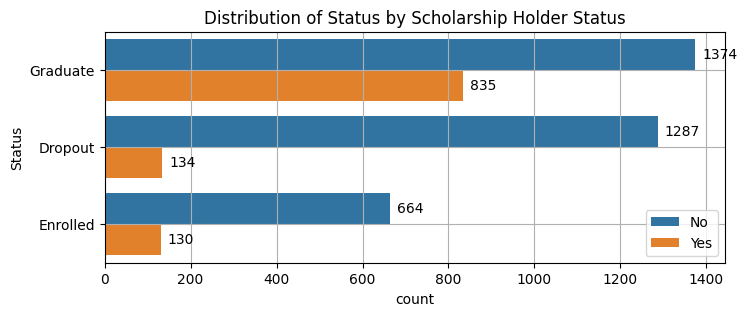

In [27]:
count_plot(df_eda, 'Status', 'Scholarship_holder', 'Status by Scholarship Holder Status', (8, 3))

Mahasiswa yang menerima beasiswa dan berstatus Graduate jumlahnya lebih banyak daripada mahasiswa yang Dropout. Jumlah mahasiswa penerima beasiswa dengan status putus sekolah dan yang saat ini Enrolled hampir sama dan jumlahnya tidak jauh berbeda.

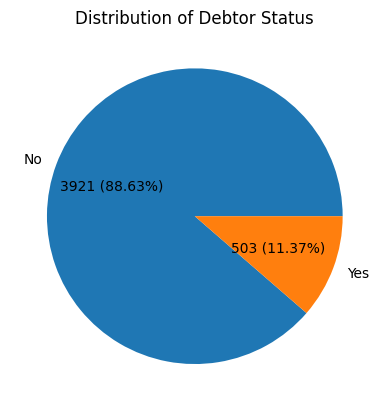

In [28]:
pie_plot(df_eda['Debtor'], 'Debtor Status')

Hanya 11,37% mahasiswa yang memiliki hutang, sedangkan 88,63% lainnya tidak memiliki hutang.

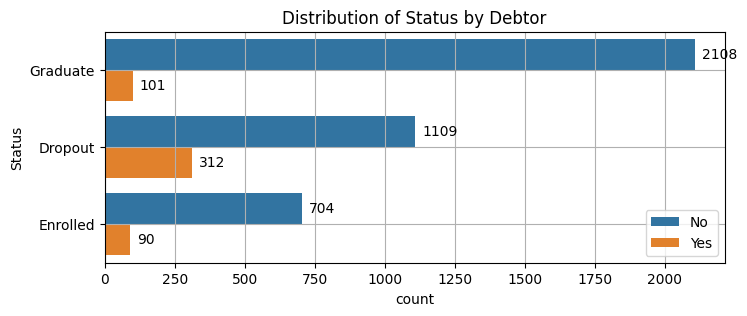

In [29]:
count_plot(df_eda, 'Status', 'Debtor', 'Status by Debtor', (8, 3))

Mahasiswa yang memiliki hutang digambarkan dengan jelas bahwa sebagian besar adalah mereka yang berstatus dropout dibandingkan dengan mereka yang lulus atau masih terdaftar. Hal ini menggambarkan adanya faktor keuangan yang sangat kuat terhadap tingkat kelulusan dan putus sekolah mahasiswa.

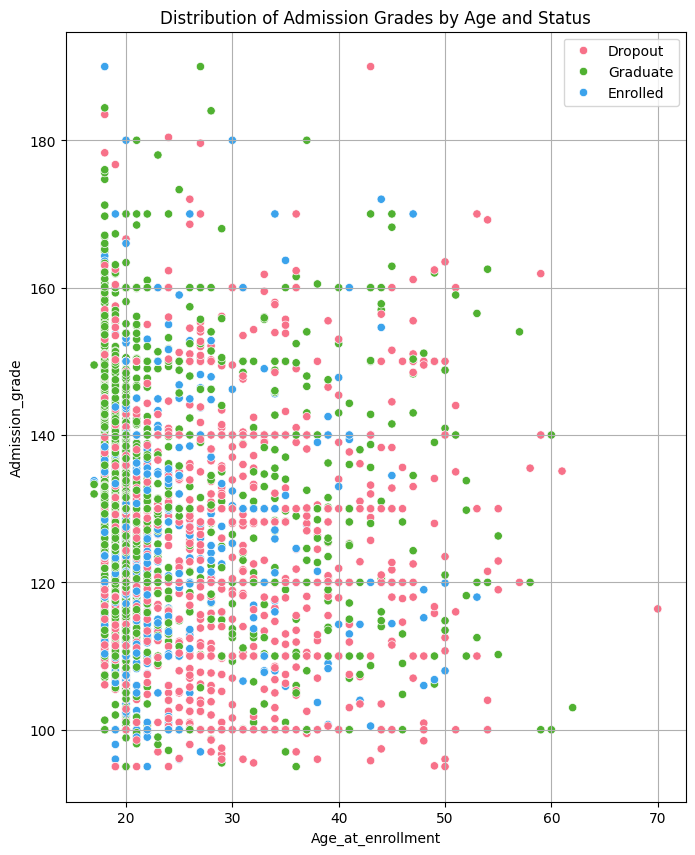

In [30]:
plt.figure(figsize=(8, 10))
sns.scatterplot(data=df_eda, x='Age_at_enrollment', y='Admission_grade',
                hue='Status', palette='husl')
plt.title('Distribution of Admission Grades by Age and Status')
plt.legend(loc='upper right')
plt.grid()

Berdasarkan scatterplot distribusi Nilai Masuk (Admission Grade) berdasarkan Usia dan Status, dapat disimpulkan bahwa rata-rata sebagian besar mahasiswa yang lulus adalah mereka yang berusia di bawah 20 hingga 25 tahun dengan rata-rata Nilai Masuk sekitar 120 hingga 160. Sementara itu, mahasiswa berusia 30 hingga 40 atau bahkan 50 tahun memiliki rata-rata Nilai Masuk 100 hingga 140 dan berstatus Dropout.

# **Data Preparation / Preprocessing**

In [31]:
df.head()

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,2
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,2
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,2


Cek label values

In [32]:
dict(zip(le.classes_, le.transform(le.classes_)))

{'Dropout': np.int64(0), 'Enrolled': np.int64(1), 'Graduate': np.int64(2)}

Keluarkan baris dengan nilai Status sama dengan 1 Enrolled dan ubah nilai Graduate dari 2 menjadi 1.

In [33]:
df = df[df['Status'] != 1]
df = df.reset_index(drop=True)

df.loc[:, 'Status'] = df['Status'].replace({2: 1})
df

,Marital_status,Application_mode,Application_order,Course,Daytime_evening_attendance,Previous_qualification,Previous_qualification_grade,Nacionality,Mothers_qualification,Fathers_qualification,...,Curricular_units_2nd_sem_credited,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Unemployment_rate,Inflation_rate,GDP,Status
0,1,17,5,171,1,1,122.0,1,19,12,...,0,0,0,0,0.000000,0,10.8,1.4,1.74,0
1,1,15,1,9254,1,1,160.0,1,1,3,...,0,6,6,6,13.666667,0,13.9,-0.3,0.79,1
2,1,1,5,9070,1,1,122.0,1,37,37,...,0,6,0,0,0.000000,0,10.8,1.4,1.74,0
3,1,17,2,9773,1,1,122.0,1,38,37,...,0,6,10,5,12.400000,0,9.4,-0.8,-3.12,1
4,2,39,1,8014,0,1,100.0,1,37,38,...,0,6,6,6,13.000000,0,13.9,-0.3,0.79,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,1,1,6,9773,1,1,125.0,1,1,1,...,0,6,8,5,12.666667,0,15.5,2.8,-4.06,1
3626,1,1,2,9773,1,1,120.0,105,1,1,...,0,6,6,2,11.000000,0,11.1,0.6,2.02,0
3627,1,1,1,9500,1,1,154.0,1,37,37,...,0,8,9,1,13.500000,0,13.9,-0.3,0.79,0
3628,1,1,1,9147,1,1,180.0,1,37,37,...,0,5,6,5,12.000000,0,9.4,-0.8,-3.12,1


In [34]:
df['Status'].value_counts()

Status
1    2209
0    1421
Name: count, dtype: int64

Dalam dataset ini, fitur label yang digunakan adalah Status, yaitu apakah mahasiswa tersebut Graduate atau Dropout.

**Feature Selection**

Filter semua fitur data yang memiliki nilai korelasi absolut kurang dari 0,1.

In [35]:
df_filtered = df.loc[:, df.corr()['Status'].abs().ge(0.1)]
df_filtered

,Marital_status,Application_mode,Previous_qualification_grade,Admission_grade,Displaced,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Status
0,1,17,122.0,127.3,1,0,1,1,0,20,0,0,0.000000,0,0,0,0.000000,0,0
1,1,15,160.0,142.5,1,0,0,1,0,19,6,6,14.000000,6,6,6,13.666667,0,1
2,1,1,122.0,124.8,1,0,0,1,0,19,6,0,0.000000,6,0,0,0.000000,0,0
3,1,17,122.0,119.6,1,0,1,0,0,20,6,6,13.428571,6,10,5,12.400000,0,1
4,2,39,100.0,141.5,0,0,1,0,0,45,6,5,12.333333,6,6,6,13.000000,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3625,1,1,125.0,122.2,0,0,1,1,0,19,6,5,13.600000,6,8,5,12.666667,0,1
3626,1,1,120.0,119.0,1,1,0,0,0,18,6,6,12.000000,6,6,2,11.000000,0,0
3627,1,1,154.0,149.5,1,0,1,0,1,30,7,7,14.912500,8,9,1,13.500000,0,0
3628,1,1,180.0,153.8,1,0,1,0,1,20,5,5,13.800000,5,6,5,12.000000,0,1


In [36]:
df_filtered.describe()

,Marital_status,Application_mode,Previous_qualification_grade,Admission_grade,Displaced,Debtor,Tuition_fees_up_to_date,Gender,Scholarship_holder,Age_at_enrollment,Curricular_units_1st_sem_enrolled,Curricular_units_1st_sem_approved,Curricular_units_1st_sem_grade,Curricular_units_2nd_sem_enrolled,Curricular_units_2nd_sem_evaluations,Curricular_units_2nd_sem_approved,Curricular_units_2nd_sem_grade,Curricular_units_2nd_sem_without_evaluations,Status
count,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000,3630.000000
mean,1.184298,18.421763,132.920606,127.293939,0.549036,0.113774,0.866116,0.344077,0.266942,23.461157,6.337466,4.791460,10.534860,6.296419,7.763085,4.518457,10.036155,0.142149,0.608540
std,0.613009,17.358595,13.238373,14.611295,0.497658,0.317580,0.340575,0.475132,0.442423,7.827994,2.570773,3.237845,5.057694,2.263020,3.964163,3.162376,5.481742,0.747670,0.488144
min,1.000000,1.000000,95.000000,95.000000,0.000000,0.000000,0.000000,0.000000,0.000000,17.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,1.000000,125.000000,118.000000,0.000000,0.000000,1.000000,0.000000,0.000000,19.000000,5.000000,3.000000,11.000000,5.000000,6.000000,2.000000,10.517857,0.000000,0.000000
50%,1.000000,17.000000,133.100000,126.500000,1.000000,0.000000,1.000000,0.000000,0.000000,20.000000,6.000000,5.000000,12.341429,6.000000,8.000000,5.000000,12.333333,0.000000,1.000000
75%,1.000000,39.000000,140.000000,135.100000,1.000000,0.000000,1.000000,1.000000,1.000000,25.000000,7.000000,6.000000,13.500000,7.000000,10.000000,6.000000,13.500000,0.000000,1.000000
max,6.000000,57.000000,190.000000,190.000000,1.000000,1.000000,1.000000,1.000000,1.000000,70.000000,26.000000,26.000000,18.875000,23.000000,33.000000,20.000000,18.571429,12.000000,1.000000


In [37]:
df_filtered.to_csv('student_data_filtered.csv', index=False)

**Data Splitting**

Bagi data menjadi variabel independen (X) dan variabel dependen (y) sebagai label.

In [38]:
X = df_filtered.drop(['Status'], axis=1)
y = df_filtered['Status']

**Data Resampling**

In [39]:
smote = SMOTE(random_state=20241124)
X_smote, y_smote = smote.fit_resample(X, y)

y_counter = collections.Counter(y)
y_smote_counter = collections.Counter(y_smote)

df_comparison = pd.DataFrame({
    'None': y_counter,
    'SMOTE': y_smote_counter
})

df_comparison.loc['Total'] = [sum(y_counter.values()), sum(y_smote_counter.values())]
df_comparison

,None,SMOTE
0,1421,2209
1,2209,2209
Total,3630,4418


**Train-Test Split**

Bagi data hasil resampling menjadi data latih (train) dan data uji (test).

In [40]:
X_train, X_test, y_train, y_test = train_test_split(
    X_smote, y_smote, test_size=0.2, random_state=20241116, stratify=y_smote)

print('X_train :', X_train.shape)
print('y_train :', y_train.shape)
print('X_test  :', X_test.shape)
print('y_test  :', y_test.shape)

X_train : (3534, 18)
y_train : (3534,)
X_test  : (884, 18)
y_test  : (884,)


**Data Standardization**

In [41]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

print(f'X_train:\n{X_train}\n')
print(f'X_test:\n{X_test}')

X_train:
[[-0.29437224  1.43984557  0.56572219 ... -0.00432693  0.60159057
  -0.18461772]
 [-0.29437224 -1.03991657  0.41333811 ...  0.61980994  0.65521521
  -0.18461772]
 [-0.29437224  1.15150114  1.3276426  ...  0.30774151  0.77970097
  -0.18461772]
 ...
 [-0.29437224 -0.69390325  0.56572219 ...  0.61980994  0.90897465
  -0.18461772]
 [-0.29437224 -1.03991657 -1.72003903 ...  0.61980994  0.43497116
  -0.18461772]
 [-0.29437224 -1.03991657  0.26095403 ...  0.61980994  0.61451794
  -0.18461772]]

X_test:
[[-0.29437224 -1.03991657 -2.4057674  ...  0.61980994  0.63606355
  -0.18461772]
 [-0.29437224  1.3245078  -0.65335046 ...  1.2439468   0.61645704
  -0.18461772]
 [-0.29437224  1.43984557  0.56572219 ... -1.25260065 -1.6046802
  -0.18461772]
 ...
 [ 1.45699391 -0.69390325 -0.95811862 ... -0.62846379  0.46369865
  -0.18461772]
 [-0.29437224 -1.03991657 -0.31926549 ... -1.25260065 -1.6046802
  -0.18461772]
 [-0.29437224 -0.52089659  0.56572219 ...  0.93187837  0.34796793
  -0.18461772]]


# **Modelling**

In [42]:
models = {
    'LR': LogisticRegression(class_weight='balanced', max_iter=10000),
    'SVM': SVC(class_weight='balanced', max_iter=10000),
    'DT': DecisionTreeClassifier(class_weight='balanced'),
    'GB': GradientBoostingClassifier(),
    'RF': RandomForestClassifier(class_weight='balanced'),
    'KNN': KNeighborsClassifier(),
    'NB': GaussianNB()
}

# Define the metrics
metrics = {metric: [] for metric in ['Accuracy', 'Precision', 'Recall', 'F1-Score']}

# Fit models and calculate metrics
for model_name, model in models.items():
    model.fit(X_train, y_train)
    pred = model.predict(X_test)

    metrics['Accuracy'].append(accuracy_score(y_test, pred))
    metrics['Precision'].append(precision_score(y_test, pred))
    metrics['Recall'].append(recall_score(y_test, pred))
    metrics['F1-Score'].append(f1_score(y_test, pred))

In [43]:
# Create a DataFrame from the collected metrics
model_metrics = pd.DataFrame(metrics, index=models.keys())
model_metrics

,Accuracy,Precision,Recall,F1-Score
LR,0.910633,0.900662,0.923077,0.911732
SVM,0.912896,0.887473,0.945701,0.915663
DT,0.866516,0.891304,0.834842,0.862150
GB,0.911765,0.893939,0.934389,0.913717
RF,0.920814,0.900862,0.945701,0.922737
KNN,0.889140,0.859833,0.929864,0.893478
NB,0.846154,0.808468,0.907240,0.855011


Random Forest Classifier mengungguli model-model lainnya dalam hal metrik evaluasi, sehingga menjadikannya model terpilih untuk digunakan.

In [44]:
model_rf = RandomForestClassifier(class_weight='balanced').fit(X_train, y_train)
model_rf

,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [45]:
y_train_rf = model_rf.predict(X_train)
y_test_rf = model_rf.predict(X_test)

# **Evaluation**

In [46]:
# @title ## **Evaluation Report Model**
def evaluation_report(y_train, y_predicted, title='Data'):
    print('Classification Report on ' + title)
    print(classification_report(y_train, y_predicted))

    plt.figure(figsize=(4, 3))
    sns.heatmap(confusion_matrix(y_train, y_predicted), annot=True, fmt='d')
    plt.title('Confusion Matrix on ' + title)
    plt.ylabel('True Label Status', fontsize=10)
    plt.xlabel('Predicted Label Status', fontsize=10)
    plt.yticks(fontsize=8)
    plt.xticks(fontsize=8)
    plt.show()

Classification Report on Training Data
              precision    recall  f1-score   support

           0       1.00      1.00      1.00      1767
           1       1.00      1.00      1.00      1767

    accuracy                           1.00      3534
   macro avg       1.00      1.00      1.00      3534
weighted avg       1.00      1.00      1.00      3534



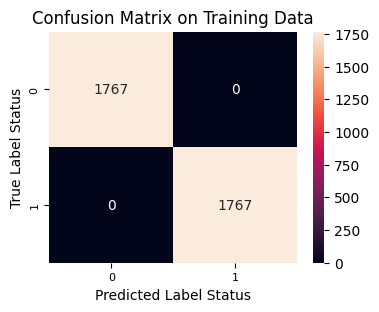

In [47]:
evaluation_report(y_train, y_train_rf, title='Training Data')

Classification Report on Testing Data
              precision    recall  f1-score   support

           0       0.93      0.90      0.91       442
           1       0.90      0.94      0.92       442

    accuracy                           0.92       884
   macro avg       0.92      0.92      0.92       884
weighted avg       0.92      0.92      0.92       884



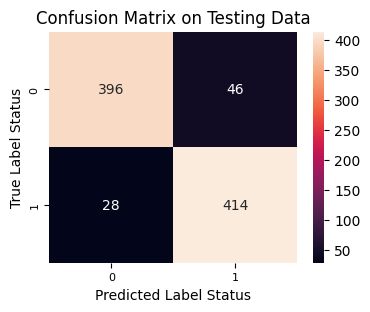

In [48]:
evaluation_report(y_test, y_test_rf, title='Testing Data')

**Hyperparameter Tuning**

In [49]:
# Hyperparameter tuning on base model using Grid Search Cross Validation
param_grid = {
    'n_estimators': [100, 250, 500],
    'criterion': ['gini', 'entropy'],
    'max_depth': [3, 10, 20],
    'min_samples_split': [2, 3, 5],
    'min_samples_leaf': [1, 2, 5, 10],
    'max_features': ['sqrt', 'log2'],
    'oob_score': [False],
    'class_weight': ['balanced']
}

clf = GridSearchCV(estimator=model_rf, param_grid=param_grid, cv=3, n_jobs=-1, verbose=3)
clf

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",RandomForestC...ht='balanced')
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'class_weight': ['balanced'], 'criterion': ['gini', 'entropy'], 'max_depth': [3, 10, ...], 'max_features': ['sqrt', 'log2'], ...}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",None
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",3
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time for each fold and pa

In [50]:
# Fit for the best model params estimators
best_model = clf.fit(X_train, y_train)
best_model.best_estimator_

Fitting 3 folds for each of 432 candidates, totalling 1296 fits


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",20
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",3
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'log2'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric(y

In [51]:
# Predict the training and testing data using the best model
y_train_best = best_model.predict(X_train)
y_test_best = best_model.predict(X_test)

Classification Report on Training Data Best Model
              precision    recall  f1-score   support

           0       1.00      0.99      1.00      1767
           1       0.99      1.00      1.00      1767

    accuracy                           1.00      3534
   macro avg       1.00      1.00      1.00      3534
weighted avg       1.00      1.00      1.00      3534



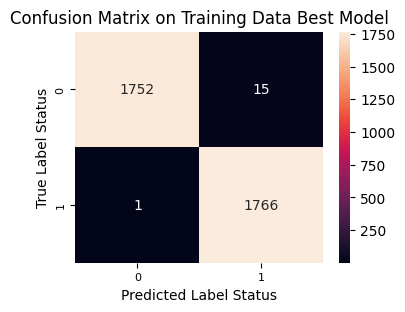

In [52]:
evaluation_report(y_train, y_train_best, title='Training Data Best Model')

Classification Report on Testing Data Best Model
              precision    recall  f1-score   support

           0       0.94      0.90      0.92       442
           1       0.90      0.94      0.92       442

    accuracy                           0.92       884
   macro avg       0.92      0.92      0.92       884
weighted avg       0.92      0.92      0.92       884



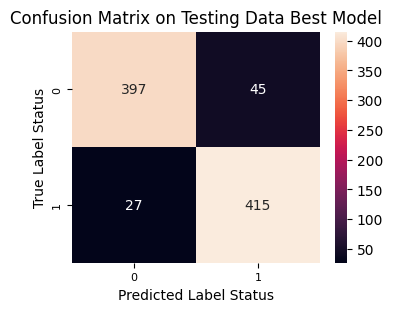

In [53]:
evaluation_report(y_test, y_test_best, title='Testing Data Best Model')

**Model Export and Project Requirements**

In [54]:
joblib.dump(best_model, 'model_rf.joblib')

['model_rf.joblib']

In [55]:
!pip freeze > requirements.txt

'pip' is not recognized as an internal or external command,
operable program or batch file.


In [56]:
# files.download('model_rf.joblib')
# files.download('requirements.txt')